# Regressão linear: PIB × Índice ABCR (Brasil, 2006–2025)

**Pergunta:** existe relação entre a atividade econômica brasileira (índice de volume do PIB) e o fluxo de veículos nas rodovias pedagiadas (Índice ABCR)?

Roteiro do notebook:
1. Fontes consultadas
2. Leitura e tratamento dos dados brutos
3. Montagem da base anual
4. Análise exploratória (dispersão e correlação)
5. Treino da regressão linear (16 anos de treino, 4 de teste, ordem cronológica)
6. Avaliação (MAE, MSE, R²) e tabela observado × previsto
7. Dificuldades encontradas e soluções
8. Conclusão

## 1. Fontes consultadas

| Indicador | Fonte | Série utilizada | Arquivo |
|---|---|---|---|
| Índice de volume do PIB | IBGE – SIDRA, [Tabela 1620](https://sidra.ibge.gov.br/tabela/1620) (Contas Nacionais Trimestrais) | Série encadeada do índice de volume trimestral, **sem ajuste sazonal**, Brasil, “PIB a preços de mercado” (base: média 1995 = 100) | `data/raw/tabela1620.csv` |
| Índice ABCR | ABCR / Tendências Consultoria – [Índice ABCR](https://melhoresrodovias.org.br/indice-abcr/) → “Ver histórico” | Aba **(C) Original** (série sem ajuste sazonal), Brasil, coluna **TOTAL** (leves + pesados), número-índice 1999 = 100, mensal | `data/raw/abcr_0826.xlsx` (edição de agosto/2026) |

O IBGE disponibiliza a série do 1º tri/1996 ao 2º tri/2026; a ABCR, de jan/1999 a ago/2026. O período comum de **20 anos completos** escolhido foi **2006–2025** (2026 ainda está incompleto nas duas fontes).

In [1]:
# ── Bibliotecas ───────────────────────────────────────────────────────────────
import pandas as pd                     # leitura e manipulação de tabelas
import numpy as np                      # cálculos numéricos (ex.: raiz do MSE)
import matplotlib.pyplot as plt         # gráficos
from sklearn.linear_model import LinearRegression                                 # modelo de regressão linear
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score     # métricas de avaliação

# ── Configurações de exibição ─────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.2f}".format)   # mostra números com 2 casas decimais
plt.rcParams.update({"figure.dpi": 110,                  # resolução dos gráficos
                     "axes.spines.top": False,           # remove borda superior
                     "axes.spines.right": False})        # remove borda direita

# ── Período de análise: 20 anos completos em comum nas duas fontes ───────────
ANO_INI, ANO_FIM = 2006, 2025

## 2. Leitura e tratamento dos dados brutos

### 2.1 PIB – Tabela 1620 (SIDRA)

O CSV exportado pelo SIDRA não é “tabular” no sentido usual: tem 3 linhas de título, os **trimestres estão nas colunas** (formato largo), o separador é `;`, o decimal é `,` e o arquivo tem BOM UTF‑8 e notas de rodapé. Por isso leio apenas as linhas de cabeçalho (trimestres) e de valores (Brasil) e transformo para o formato longo.

In [2]:
# Lê só as 3 linhas úteis do CSV do SIDRA:
#   linha 0 → rótulos dos trimestres | linha 1 → nome da variável | linha 2 → valores do Brasil
# skiprows=3 pula os títulos; utf-8-sig remove o BOM; dtype=str evita conversões erradas (decimal com vírgula)
raw = pd.read_csv("data/raw/tabela1620.csv", sep=";", skiprows=3, nrows=3,
                  header=None, encoding="utf-8-sig", dtype=str)

trimestres = raw.iloc[0, 1:]          # "1º trimestre 1996", ... (a coluna 0 é vazia, por isso 1:)
variavel   = raw.iloc[1, 1:]          # "PIB a preços de mercado" em todas as colunas
valores    = raw.iloc[2, 1:]          # índices de volume do Brasil

# Verificações de segurança: garantem que pegamos a variável e a localidade certas
assert (variavel == "PIB a preços de mercado").all()
assert raw.iloc[2, 0] == "Brasil"

# Converte do formato largo (trimestres nas colunas) para o formato longo (um trimestre por linha)
pib_tri = pd.DataFrame({
    "trimestre": trimestres.values,
    "PIB_indice": valores.str.replace(",", ".").astype(float).values,   # vírgula decimal → ponto
})
pib_tri["ano"] = pib_tri["trimestre"].str[-4:].astype(int)   # últimos 4 caracteres = ano
pib_tri["tri"] = pib_tri["trimestre"].str[0].astype(int)     # primeiro caractere = nº do trimestre

print(f"{len(pib_tri)} trimestres: {pib_tri.trimestre.iloc[0]} até {pib_tri.trimestre.iloc[-1]}")
pib_tri.tail(8)   # mostra os últimos 8 trimestres para conferência

122 trimestres: 1º trimestre 1996 até 2º trimestre 2026


,trimestre,PIB_indice,ano,tri
114,3º trimestre 2024,195.10,2024,3
115,4º trimestre 2024,189.45,2024,4
116,1º trimestre 2025,191.02,2025,1
117,2º trimestre 2025,195.18,2025,2
118,3º trimestre 2025,198.66,2025,3
119,4º trimestre 2025,192.94,2025,4
120,1º trimestre 2026,194.53,2026,1
121,2º trimestre 2026,199.05,2026,2


### 2.2 ABCR – planilha histórica

A planilha tem quatro abas: gráficos, quadros‑resumo, **(C) Original** e (D) Dessazonalizado. O enunciado pede a série **sem ajuste sazonal**, portanto uso a aba **(C) Original**. As três primeiras linhas são cabeçalhos mesclados (região / descrição / LEVES‑PESADOS‑TOTAL); para Brasil a coluna de **TOTAL** é a 4ª (índice 3).

In [3]:
# Lê as 3 linhas de cabeçalho da aba "(C) Original" para confirmar qual coluna usar
cab = pd.read_excel("data/raw/abcr_0826.xlsx", sheet_name="(C) Original", header=None, nrows=3)
print(cab.iloc[:, :4].to_string())   # confere que col. 3 = Brasil / série original / TOTAL
assert cab.iloc[0, 1] == "Brasil" and cab.iloc[2, 3] == "TOTAL"   # trava caso o layout mude

# Lê os dados mensais: coluna 0 = data do mês, coluna 3 = índice TOTAL do Brasil
abcr_mes = pd.read_excel("data/raw/abcr_0826.xlsx", sheet_name="(C) Original",
                         header=None, skiprows=3, usecols=[0, 3], names=["mes", "ABCR_indice"])
abcr_mes = abcr_mes.dropna()                          # remove linhas vazias no fim da planilha
abcr_mes["mes"] = pd.to_datetime(abcr_mes["mes"])     # garante tipo data
abcr_mes["ano"] = abcr_mes["mes"].dt.year             # extrai o ano para agregar depois

print(f"{len(abcr_mes)} meses: {abcr_mes.mes.min():%m/%Y} até {abcr_mes.mes.max():%m/%Y}")
abcr_mes.tail(8)   # mostra os últimos 8 meses para conferência

    0                                          1        2      3
0 NaN                                     Brasil      NaN    NaN
1 NaN  Série original - número índice (1999=100)      NaN    NaN
2 NaN                                      LEVES  PESADOS  TOTAL
332 meses: 01/1999 até 08/2026


,mes,ABCR_indice,ano
324,2026-01-01,186.65,2026
325,2026-02-01,161.54,2026
326,2026-03-01,173.34,2026
327,2026-04-01,173.27,2026
328,2026-05-01,171.75,2026
329,2026-06-01,163.50,2026
330,2026-07-01,181.67,2026
331,2026-08-01,177.76,2026


## 3. Montagem da base anual

* `PIB_indice` = média dos **4** índices trimestrais do ano;
* `ABCR_indice` = média dos **12** índices mensais do ano.

Antes de calcular as médias, confiro se cada ano do período tem todos os períodos disponíveis (sem isso, a média de um ano incompleto ficaria distorcida pela sazonalidade).

In [4]:
# Agrega por ano: conta quantos períodos existem e calcula a média
pib_ano  = pib_tri.groupby("ano")["PIB_indice"].agg(n_trimestres="count", PIB_indice="mean")    # média de 4 trimestres
abcr_ano = abcr_mes.groupby("ano")["ABCR_indice"].agg(n_meses="count", ABCR_indice="mean")      # média de 12 meses

# Junta as duas fontes (outer = mantém todos os anos para enxergar onde falta dado)
cobertura = pib_ano.join(abcr_ano, how="outer")
print("Anos incompletos em alguma fonte:")
print(cobertura[(cobertura.n_trimestres != 4) | (cobertura.n_meses != 12)][["n_trimestres", "n_meses"]])

# Recorta 2006–2025 e garante que todos os anos estão completos nas duas séries
base = cobertura.loc[ANO_INI:ANO_FIM]
assert (base.n_trimestres == 4).all() and (base.n_meses == 12).all() and len(base) == 20

# Mantém só as colunas pedidas, renomeia e salva a base tratada
base = base[["PIB_indice", "ABCR_indice"]].reset_index().rename(columns={"ano": "Ano"})
base.to_csv("data/processed/base_anual_pib_abcr.csv", index=False)
base

Anos incompletos em alguma fonte:
      n_trimestres  n_meses
ano                        
1996             4      NaN
1997             4      NaN
1998             4      NaN
2026             2     8.00


,Ano,PIB_indice,ABCR_indice
0,2006,133.35,107.49
1,2007,141.45,113.99
2,2008,148.65,120.91
3,2009,148.47,123.60
4,2010,159.64,133.12
5,2011,165.99,141.44
6,2012,169.18,147.97
7,2013,174.26,153.59
8,2014,175.14,157.23
9,2015,168.93,154.25


Os anos 1996–1998 não têm ABCR e 2026 está incompleto nas duas fontes (2 trimestres / 8 meses), por isso ficam de fora. A base final, com 20 anos e nenhum valor faltante, foi salva em `data/processed/base_anual_pib_abcr.csv`.

> Observação: as duas séries têm bases diferentes (PIB: média 1995 = 100; ABCR: 1999 = 100). Isso não atrapalha a regressão — o coeficiente angular e o intercepto absorvem a diferença de escala — mas impede comparar os níveis diretamente (ex.: PIB = 194 e ABCR = 173 não significam que o PIB “cresceu mais”).

## 4. Análise da relação

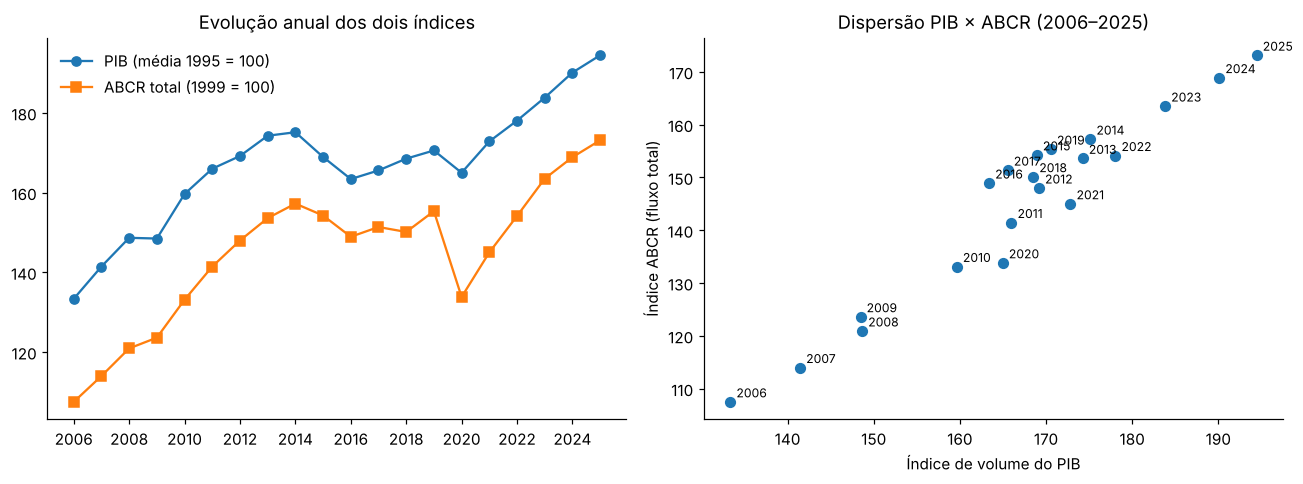

Correlação de Pearson (2006–2025): r = 0.9641   |   r² = 0.9295


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))   # dois gráficos lado a lado

# Gráfico 1: evolução das duas séries ao longo do tempo
ax[0].plot(base.Ano, base.PIB_indice, marker="o", label="PIB (média 1995 = 100)")
ax[0].plot(base.Ano, base.ABCR_indice, marker="s", label="ABCR total (1999 = 100)")
ax[0].set_title("Evolução anual dos dois índices")
ax[0].set_xticks(base.Ano[::2]); ax[0].legend(frameon=False)   # rótulos do eixo x a cada 2 anos

# Gráfico 2: dispersão (PIB no eixo x, ABCR no eixo y), com o ano escrito ao lado de cada ponto
ax[1].scatter(base.PIB_indice, base.ABCR_indice, s=40)
for _, r in base.iterrows():
    ax[1].annotate(int(r.Ano), (r.PIB_indice, r.ABCR_indice), xytext=(4, 3),
                   textcoords="offset points", fontsize=8)
ax[1].set_xlabel("Índice de volume do PIB"); ax[1].set_ylabel("Índice ABCR (fluxo total)")
ax[1].set_title("Dispersão PIB × ABCR (2006–2025)")
plt.tight_layout(); plt.savefig("img/series_e_dispersao.png", bbox_inches="tight"); plt.show()   # salva em img/

# Correlação de Pearson: mede a força da relação linear (−1 a 1)
r = base["PIB_indice"].corr(base["ABCR_indice"])
print(f"Correlação de Pearson (2006–2025): r = {r:.4f}   |   r² = {r**2:.4f}")

**Leitura:** a dispersão mostra uma relação **positiva, forte e aproximadamente linear** (r ≈ 0,96): anos com maior produção tendem a ter mais veículos nas rodovias. Os pontos acompanham inclusive a recessão de 2015–2016, quando ambos caíram.

O ponto mais afastado da tendência é **2020**: o PIB recuou ~3%, mas o fluxo de veículos caiu ~14%, por causa das restrições de circulação da pandemia — um choque que afetou muito mais a mobilidade do que a produção. A partir de 2021 os pontos voltam a seguir uma linha paralela, porém ligeiramente **abaixo** da tendência anterior (para o mesmo PIB, um pouco menos de fluxo).

## 5. Treinamento do modelo

* **X** = `PIB_indice`, **y** = `ABCR_indice`
* Treino: os **16 primeiros anos** (2006–2021); teste: os **4 últimos** (2022–2025)
* Divisão por posição, **sem embaralhar** — em séries temporais o modelo deve ser avaliado em anos posteriores aos que viu, simulando uma previsão real. (Por isso não usei `train_test_split` com `shuffle=True`.)

In [6]:
# X precisa ser 2D (DataFrame, por isso colchetes duplos); y é 1D (Series)
X = base[["PIB_indice"]]
y = base["ABCR_indice"]

# Divisão cronológica por posição (sem embaralhar): 16 primeiros anos = treino, 4 últimos = teste
X_train, X_test = X.iloc[:16], X.iloc[16:]
y_train, y_test = y.iloc[:16], y.iloc[16:]
print("Treino:", base.Ano.iloc[0], "–", base.Ano.iloc[15], f"({len(X_train)} anos)")
print("Teste: ", base.Ano.iloc[16], "–", base.Ano.iloc[-1], f"({len(X_test)} anos)")

# Cria e treina o modelo: encontra a reta y = b + a·x que minimiza o erro quadrático no treino
modelo = LinearRegression()
modelo.fit(X_train, y_train)

a, b = modelo.coef_[0], modelo.intercept_   # a = inclinação, b = intercepto
print(f"\nEquação ajustada:  ABCR = {b:.2f} + {a:.4f} × PIB")
print(f"R² no treino: {modelo.score(X_train, y_train):.4f}")   # quanto a reta explica dos dados de treino

Treino: 2006 – 2021 (16 anos)
Teste:  2022 – 2025 (4 anos)

Equação ajustada:  ABCR = -56.79 + 1.2145 × PIB
R² no treino: 0.9009


**Interpretação dos coeficientes:** cada ponto a mais no índice do PIB está associado, em média, a ~1,21 ponto a mais no Índice ABCR. Em termos relativos (nos níveis médios das séries), um crescimento de 1% no PIB corresponde a algo como 1,3% de aumento no fluxo — o tráfego rodoviário oscilou um pouco mais que o PIB no período. O intercepto negativo não tem interpretação econômica (PIB = 0 está muito fora do intervalo observado); ele só posiciona a reta.

## 6. Avaliação dos resultados

In [7]:
# Usa o modelo treinado para estimar o ABCR dos 4 anos de teste
y_pred = modelo.predict(X_test)

# Tabela observado × previsto, com erro absoluto e percentual
resultado = pd.DataFrame({
    "Ano": base.Ano.iloc[16:].values,
    "PIB_indice": X_test.PIB_indice.values,
    "ABCR_observado": y_test.values,
    "ABCR_previsto": y_pred,
})
resultado["erro (obs − prev)"] = resultado.ABCR_observado - resultado.ABCR_previsto   # negativo = modelo superestimou
resultado["erro %"] = 100 * resultado["erro (obs − prev)"] / resultado.ABCR_observado
resultado.to_csv("data/processed/resultado_teste.csv", index=False)   # salva a tabela

# Métricas no conjunto de teste
mae  = mean_absolute_error(y_test, y_pred)   # erro médio absoluto (mesma unidade do índice)
mse  = mean_squared_error(y_test, y_pred)    # erro quadrático médio (penaliza erros grandes)
rmse = np.sqrt(mse)                          # raiz do MSE, volta à unidade do índice
r2   = r2_score(y_test, y_pred)              # proporção da variância do teste explicada pelo modelo

display(resultado)
print(f"MAE  = {mae:.3f} pontos de índice")
print(f"MSE  = {mse:.3f} (pontos²)   → RMSE = {rmse:.3f} pontos")
print(f"R²   = {r2:.4f}")
print(f"Erro médio percentual absoluto (MAPE) = {resultado['erro %'].abs().mean():.2f}%")

,Ano,PIB_indice,ABCR_observado,ABCR_previsto,erro (obs − prev),erro %
0,2022,178.05,154.12,159.46,-5.34,-3.46
1,2023,183.82,163.49,166.47,-2.98,-1.82
2,2024,190.10,168.88,174.10,-5.22,-3.09
3,2025,194.45,173.12,179.38,-6.26,-3.62


MAE  = 4.949 pontos de índice
MSE  = 25.950 (pontos²)   → RMSE = 5.094 pontos
R²   = 0.4849
Erro médio percentual absoluto (MAPE) = 3.00%


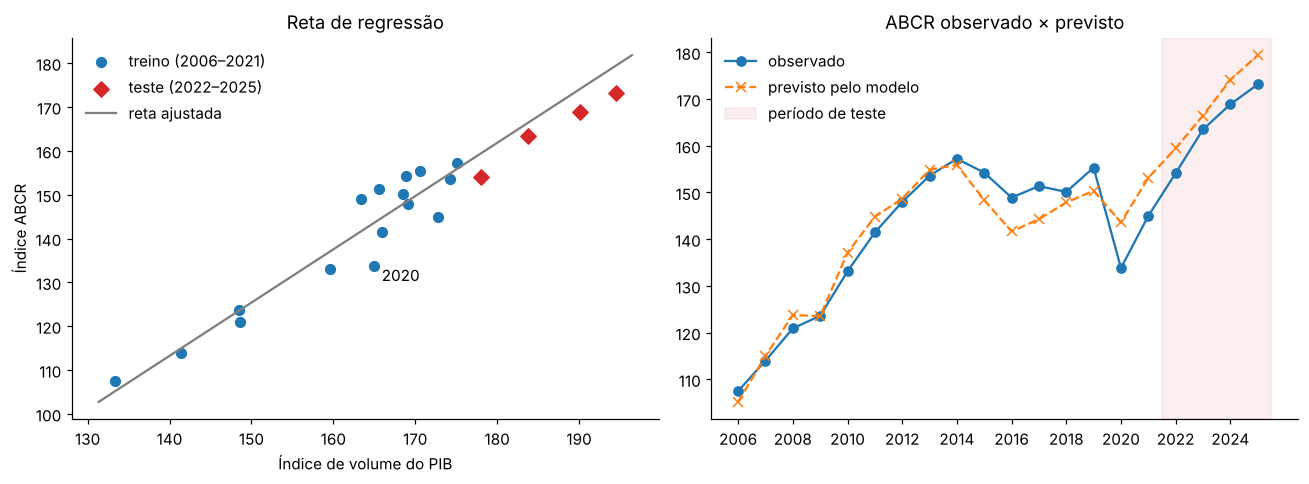

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: pontos de treino e teste + reta ajustada
xs = np.linspace(base.PIB_indice.min() - 2, base.PIB_indice.max() + 2, 100)   # valores de PIB para desenhar a reta
ax[0].scatter(X_train, y_train, label="treino (2006–2021)", s=40)
ax[0].scatter(X_test, y_test, label="teste (2022–2025)", s=50, marker="D", color="C3")
ax[0].plot(xs, modelo.predict(pd.DataFrame({"PIB_indice": xs})), color="gray", lw=1.5, label="reta ajustada")
ax[0].annotate("2020", (base.PIB_indice[14], base.ABCR_indice[14]), xytext=(5, -10), textcoords="offset points")  # destaca a pandemia
ax[0].set_xlabel("Índice de volume do PIB"); ax[0].set_ylabel("Índice ABCR")
ax[0].set_title("Reta de regressão"); ax[0].legend(frameon=False)

# Gráfico 2: série observada × valores previstos pelo modelo em todos os anos
ax[1].plot(base.Ano, y, marker="o", label="observado")
ax[1].plot(base.Ano, modelo.predict(X), marker="x", ls="--", label="previsto pelo modelo")
ax[1].axvspan(2021.5, 2025.5, color="C3", alpha=0.08, label="período de teste")   # sombreia os anos de teste
ax[1].set_title("ABCR observado × previsto"); ax[1].set_xticks(base.Ano[::2]); ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig("img/regressao_e_previsao.png", bbox_inches="tight"); plt.show()

### O que significam as métricas

* **MAE (erro absoluto médio)** – média de |observado − previsto|, na mesma unidade do índice. Um MAE de ~4,9 pontos significa que, em média, a previsão errou ~4,9 pontos em índices da ordem de 155–175, ou seja, **cerca de 3%**.
* **MSE (erro quadrático médio)** – média dos erros ao quadrado (~26 pontos²). Penaliza mais os erros grandes; como está em unidade ao quadrado, é mais fácil interpretar a raiz (**RMSE ≈ 5,1 pontos**). MAE e RMSE muito próximos indicam que os erros têm tamanho parecido entre si — não há um único ano “estragando” o resultado.
* **R² (coeficiente de determinação)** – proporção da variância de y **no conjunto de teste** que o modelo explica, comparada a simplesmente prever a média dos 4 anos de teste. R² = 1 seria perfeito; R² = 0 equivale a chutar a média; valores negativos seriam piores que a média. O valor obtido, **≈ 0,48**, é moderado.

### O modelo ficou próximo dos dados reais?

Em parte. O modelo **acertou a direção e o ritmo** do crescimento — prevê alta contínua de 2022 a 2025, e a inclinação prevista é parecida com a observada — e os erros ficaram entre ~1,8% e ~3,6% do valor observado. Porém **todos os quatro erros têm o mesmo sinal**: o modelo **superestimou** o fluxo em todos os anos de teste, em ~3–6 pontos. Um viés sistemático assim explica o R² apenas moderado: com só 4 pontos no teste e pouca variância entre eles (154 a 173), um deslocamento constante pesa muito no R².

A causa mais provável é uma **mudança de patamar após a pandemia**: o modelo aprendeu a relação de 2006–2019, quando um dado nível de PIB vinha acompanhado de mais tráfego. Depois de 2020 a economia cresceu, mas parte da mobilidade não voltou (trabalho remoto/híbrido, mais serviços digitais, composição do PIB mais puxada por agropecuária e serviços). O ano de 2020 ainda está no treino e puxa a reta, mas por ser um único ponto não basta para “ensinar” esse novo patamar.

## 7. Dificuldades encontradas e soluções adotadas

| Dificuldade | Solução |
|---|---|
| CSV do SIDRA em formato largo (trimestres nas colunas), com linhas de título, rodapé com legenda, BOM UTF‑8, separador `;` e decimal `,`. | Leitura apenas das linhas relevantes (`skiprows=3, nrows=3`, `encoding="utf-8-sig"`), troca de `,` por `.` e conversão para formato longo; ano extraído do rótulo do trimestre. Asserções conferem que a linha é “Brasil” e a variável é “PIB a preços de mercado”. |
| Planilha da ABCR com várias abas, cabeçalhos mesclados em 3 linhas e várias regiões lado a lado. | Escolha da aba **(C) Original** (sem ajuste sazonal, conforme pedido) e da coluna Brasil/TOTAL, com conferência programática do cabeçalho antes de ler os dados. |
| Escolher entre série original e dessazonalizada. | Original, como pede o enunciado. Como a média anual de 12 meses (ou 4 trimestres) já cancela a sazonalidade, o ajuste sazonal não é necessário para dados anuais. |
| Períodos incompletos: ABCR começa em 1999 e 2026 tem só 8 meses / 2 trimestres. | Contagem de meses e trimestres por ano antes de agregar; filtro 2006–2025 com `assert` garantindo 4 trimestres e 12 meses em todos os 20 anos. |
| Bases diferentes (1995 = 100 × 1999 = 100). | Mantidas como estão; a regressão linear absorve a diferença de escala. Fica registrado que os níveis não são comparáveis entre si. |
| Divisão treino/teste em série temporal. | Fatiamento por posição (`iloc[:16]` / `iloc[16:]`), sem embaralhar. |
| Ano atípico (2020, pandemia) dentro do treino. | Mantido para respeitar o enunciado e não “escolher” dados a dedo; discutido na análise como fonte de ruído e de possível mudança estrutural. |

## 8. Conclusão

* Existe uma **associação positiva e forte** entre a atividade econômica e o fluxo de veículos nas rodovias pedagiadas: correlação de **0,96** entre 2006 e 2025, e o PIB sozinho explica ~90% da variação do Índice ABCR no treino.
* A regressão `ABCR ≈ −56,8 + 1,21 × PIB`, treinada em 2006–2021, previu 2022–2025 com **MAE ≈ 4,9 pontos (~3%)**, **MSE ≈ 26,0** e **R² ≈ 0,48**. O modelo captou bem a tendência de crescimento, mas **superestimou sistematicamente** o fluxo no período de teste, sugerindo que após a pandemia o mesmo nível de PIB passou a gerar um pouco menos tráfego rodoviário.
* **Correlação não é causalidade.** As duas séries crescem juntas em parte porque compartilham uma tendência de longo prazo (crescimento populacional, expansão da frota, concessões novas incorporadas ao índice) e respondem aos mesmos choques. A relação também pode ir nos dois sentidos — mais produção gera mais transporte de carga, mas o transporte também é parte da produção. Para afirmar causa seria preciso outro desenho de estudo.
* Limitações: apenas 20 observações anuais e 4 de teste; um único preditor; séries com tendência (o que infla a correlação). Possíveis extensões: usar dados trimestrais/mensais (mais observações), modelar variações percentuais em vez de níveis, separar veículos **pesados** (mais ligados à produção) de leves, e incluir uma variável indicadora para o período pós‑2020.